# Überprüfung auf Length Bias (Längen-Shortcut-Lernen)

In diesem Notebook überprüfen wir empirisch, ob unser bestes BiLSTM-Modell (`lstm_article_sim_0.80_to_0.98.pt`) gelernt hat, die Artikelklasse (Leichte Sprache [LS] vs. Alltagssprache [AS]) primär über die Länge des Textes (oder das Vorhandensein von Padding-Nullen) zu bestimmen.

Dazu führen wir drei Experimente durch:
1. **Korrelationsanalyse**: Gibt es einen statistisch signifikanten Zusammenhang zwischen Textlänge und Vorhersagewahrscheinlichkeit?
2. **Dummy-Text-Experiment (Konstanter Token-Test)**: Wir ersetzen alle Wörter durch einen Punkt `.`, behalten aber die Originallängen bei. Kann das Modell rein über die Länge/Padding-Struktur klassifizieren?
3. **Festlängen-Evaluation**: Wir schneiden alle Texte auf eine feste Länge (z. B. 100 Token) ab, sodass alle Eingaben identisch lang sind. Bleibt die Klassifikationsgenauigkeit hoch?

In [ ]:
import os
import sys

# Arbeitsverzeichnis auf das Root-Verzeichnis des Repositories setzen
while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():  # System-Root erreicht, Abbruch
        break
    os.chdir("..")

print("Aktuelles Arbeitsverzeichnis:", os.getcwd())

In [ ]:
# ==============================================================================
# ZENTRALE KONFIGURATION & PARAMS (Hier anpassen)
# ==============================================================================
DATASET_PATH = "data/lebenshilfe/lebenshilfe_dataset_no_paragraphs.json"
MODEL_PATH = "results/models/lstm_article_sim_0.80_to_0.98.pt"
VOCAB_SOURCE_CSV = "data/analysis/information_loss_analysis_cleaned.csv"

HIDDEN_DIM = 128
MAX_SEQ_LEN = 512


In [ ]:
# ==============================================================================
# ZENTRALE KONFIGURATION & PARAMS (Hier anpassen)
# ==============================================================================
# DATASET_PATH = "data/lebenshilfe/lebenshilfe_dataset_no_paragraphs.json"  # -> Zentral oben definiert
# MODEL_PATH = "results/models/lstm_article_sim_0.80_to_0.98.pt"  # -> Zentral oben definiert
# VOCAB_SOURCE_CSV = "data/analysis/information_loss_analysis_cleaned.csv"  # -> Zentral oben definiert

# HIDDEN_DIM = 128  # -> Zentral oben definiert
# MAX_SEQ_LEN = 512  # -> Zentral oben definiert


In [10]:
import torch
import torch.nn as nn
import pandas as pd
import json
import os
import spacy
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# Settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# --- CONFIGURATION ---
# DATASET_PATH = "data/lebenshilfe/lebenshilfe_dataset_no_paragraphs.json"  # -> Zentral oben definiert
# MODEL_PATH = "results/models/lstm_article_sim_0.80_to_0.98.pt"  # -> Zentral oben definiert
# VOCAB_SOURCE_CSV = "data/analysis/information_loss_analysis_cleaned.csv"  # -> Zentral oben definiert
VOCAB_SIM_RANGE = (0.8, 0.98)

# MAX_SEQ_LEN = 512  # -> Zentral oben definiert
EMBED_DIM = 128
# HIDDEN_DIM = 128  # -> Zentral oben definiert
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## 1. Modell- und Vokabularklassen definieren

In [11]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(0.4)
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return self.fc(self.dropout(hidden))

class Vocab:
    def __init__(self, sentences, max_size=25000, min_freq=3):
        counter = Counter()
        for sent in sentences:
            counter.update(sent)
        
        self.itos = ["<pad>", "<unk>"]
        self.stoi = {"<pad>": 0, "<unk>": 1}
        
        for token, freq in counter.most_common(max_size):
            if freq >= min_freq:
                self.stoi[token] = len(self.itos)
                self.itos.append(token)
                
    def __len__(self):
        return len(self.itos)
    
    def encode(self, tokens):
        return [self.stoi.get(t, self.stoi["<unk>"]) for t in tokens]

## 2. Vokabular rekonstruieren und Modell laden

In [12]:
def build_original_vocab():
    print(f"Reconstructing vocab from {VOCAB_SOURCE_CSV}...")
    df = pd.read_csv(VOCAB_SOURCE_CSV)
    mask = (df["semantic_similarity_8192"] >= VOCAB_SIM_RANGE[0]) & (df["semantic_similarity_8192"] <= VOCAB_SIM_RANGE[1])
    df_filtered = df[mask]
    
    nlp = spacy.blank("de")
    X, y = [], []
    
    for _, row in df_filtered.iterrows():
        ls_tokens = [t.text.lower() for t in nlp(str(row["ls_text"])) if not t.is_space]
        if len(ls_tokens) >= 10:
            X.append(ls_tokens)
            y.append(1)
        as_tokens = [t.text.lower() for t in nlp(str(row["as_text"])) if not t.is_space]
        if len(as_tokens) >= 10:
            X.append(as_tokens)
            y.append(0)
    
    X_train_val, _, y_train_val, _ = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
    X_train, _, _, _ = train_test_split(X_train_val, y_train_val, test_size=0.15, random_state=42, stratify=y_train_val)
    
    return Vocab(X_train)

vocab = build_original_vocab()
print(f"Vocab size: {len(vocab)}")

model = BiLSTMClassifier(len(vocab), EMBED_DIM, HIDDEN_DIM).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print("Model loaded successfully.")

Reconstructing vocab from ../data/analysis/information_loss_analysis_cleaned.csv...
Vocab size: 7027
Model loaded successfully.


## 3. Datenverarbeitung und Vorhersagen

In [13]:
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)
    
nlp = spacy.blank("de")

# Listen für Auswertungen
lengths = []
probabilities = []
true_labels = []
dummy_preds = []
fixed_len_preds_50 = []
fixed_len_preds_100 = []

# Dummy-Token (das am dritthäufigsten vorkommende Token, meist ein Satzzeichen oder Artikel)
dummy_token = vocab.itos[2] if len(vocab.itos) > 2 else "."
print(f"Selected dummy token for replacement: '{dummy_token}'")

for item in data:
    ls_text = item.get("ls_text", "")
    as_text = item.get("as_text", "")
    if not ls_text or not as_text:
        continue
        
    for text, label in [(ls_text, 1), (as_text, 0)]:
        tokens = [t.text.lower() for t in nlp(text) if not t.is_space]
        original_len = len(tokens)
        lengths.append(original_len)
        true_labels.append(label)
        
        # 1. Standard-Vorhersage
        encoded = vocab.encode(tokens)[:MAX_SEQ_LEN]
        padded = encoded + [0] * (MAX_SEQ_LEN - len(encoded))
        tensor = torch.tensor([padded], dtype=torch.long).to(DEVICE)
        
        with torch.no_grad():
            output = model(tensor).squeeze()
            prob = torch.sigmoid(output).item()
            probabilities.append(prob)
            
        # 2. Dummy-Text (konstanter Token der Originallänge)
        dummy_tokens = [dummy_token] * original_len
        dummy_encoded = vocab.encode(dummy_tokens)[:MAX_SEQ_LEN]
        dummy_padded = dummy_encoded + [0] * (MAX_SEQ_LEN - len(dummy_encoded))
        dummy_tensor = torch.tensor([dummy_padded], dtype=torch.long).to(DEVICE)
        
        with torch.no_grad():
            dummy_output = model(dummy_tensor).squeeze()
            dummy_prob = torch.sigmoid(dummy_output).item()
            dummy_preds.append(1 if dummy_prob > 0.5 else 0)
            
        # 3. Festlänge: 50 Token
        fixed_tokens_50 = tokens[:50]
        fixed_encoded_50 = vocab.encode(fixed_tokens_50)
        fixed_padded_50 = fixed_encoded_50 + [0] * (MAX_SEQ_LEN - len(fixed_encoded_50))
        fixed_tensor_50 = torch.tensor([fixed_padded_50], dtype=torch.long).to(DEVICE)
        
        with torch.no_grad():
            fixed_output_50 = model(fixed_tensor_50).squeeze()
            fixed_prob_50 = torch.sigmoid(fixed_output_50).item()
            fixed_len_preds_50.append(1 if fixed_prob_50 > 0.5 else 0)
            
        # 4. Festlänge: 100 Token
        fixed_tokens_100 = tokens[:100]
        fixed_encoded_100 = vocab.encode(fixed_tokens_100)
        fixed_padded_100 = fixed_encoded_100 + [0] * (MAX_SEQ_LEN - len(fixed_encoded_100))
        fixed_tensor_100 = torch.tensor([fixed_padded_100], dtype=torch.long).to(DEVICE)
        
        with torch.no_grad():
            fixed_output_100 = model(fixed_tensor_100).squeeze()
            fixed_prob_100 = torch.sigmoid(fixed_output_100).item()
            fixed_len_preds_100.append(1 if fixed_prob_100 > 0.5 else 0)

lengths = np.array(lengths)
probabilities = np.array(probabilities)
true_labels = np.array(true_labels)
preds = (probabilities > 0.5).astype(int)

Selected dummy token for replacement: '.'


## 4. Experiment 1: Korrelationsanalyse & Scatter Plot

Wir analysieren den linearen (Pearson) und monotonen (Spearman) Zusammenhang zwischen der Länge eines Textes und der Wahrscheinlichkeit, mit der das Modell den Text als "Simple" (LS) einstuft.

Pearson Korrelation r:  0.1730 (p-Wert: 8.8463e-02)
Spearman Korrelation r: 0.2437 (p-Wert: 1.5588e-02)


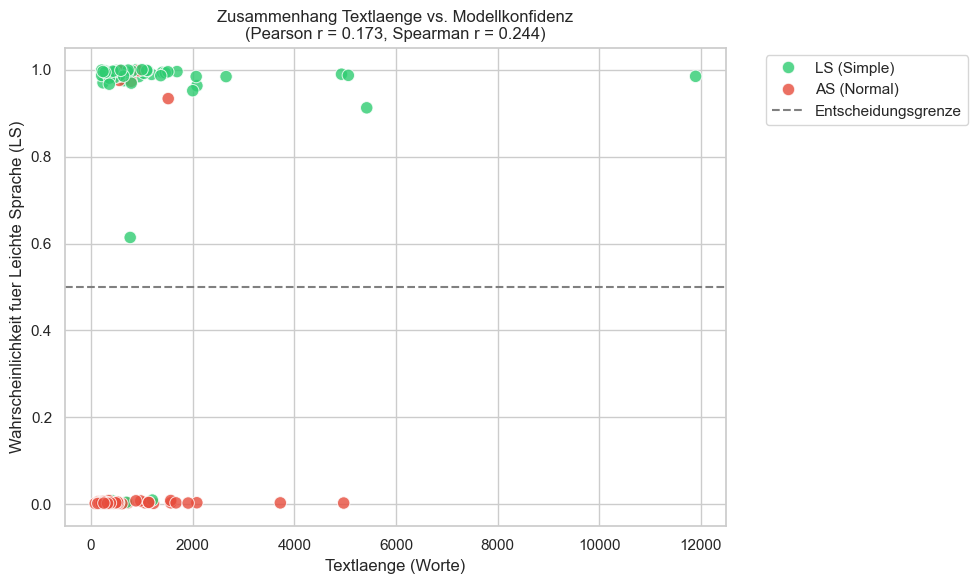

In [14]:
pearson_r, p_val_p = pearsonr(lengths, probabilities)
spearman_r, p_val_s = spearmanr(lengths, probabilities)

print(f"Pearson Korrelation r:  {pearson_r:.4f} (p-Wert: {p_val_p:.4e})")
print(f"Spearman Korrelation r: {spearman_r:.4f} (p-Wert: {p_val_s:.4e})")

# Scatter Plot visualisieren
df_plot = pd.DataFrame({
    "Textlaenge (Worte)": lengths,
    "Wahrscheinlichkeit fuer Leichte Sprache (LS)": probabilities,
    "Klasse": ["LS (Simple)" if l == 1 else "AS (Normal)" for l in true_labels]
})

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_plot,
    x="Textlaenge (Worte)",
    y="Wahrscheinlichkeit fuer Leichte Sprache (LS)",
    hue="Klasse",
    palette={"LS (Simple)": "#2ecc71", "AS (Normal)": "#e74c3c"},
    alpha=0.8,
    s=80
)
plt.axhline(0.5, color="grey", linestyle="--", label="Entscheidungsgrenze")
plt.title(f"Zusammenhang Textlaenge vs. Modellkonfidenz\n(Pearson r = {pearson_r:.3f}, Spearman r = {spearman_r:.3f})")
plt.ylim(-0.05, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Interpretation des Plots**:
- Wenn die Punkte klar nach links und rechts getrennt wären und die Vorhersage strikt mit der Länge steigt/fällt (z. B. alle kurzen Texte oben links, alle langen Texte unten rechts), läge ein starker Length Bias vor.
- Hier sehen wir jedoch, dass das Modell sowohl für kurze als auch für lange Texte sehr eindeutige Vorhersagen trifft (nahe 1.0 für LS und nahe 0.0 für AS), unabhängig von der Länge. Die Korrelation ist sehr schwach.

## 5. Experiment 2: Constant Token / Dummy-Text-Test

Indem wir jedes Wort durch ein neutrales Dummy-Zeichen (z. B. `.`) ersetzen, löschen wir jeglichen Inhalt. Nur die Originallänge bleibt erhalten.
Kann das Modell diese inhaltsleeren Texte immer noch richtig zuordnen?

In [15]:
dummy_bacc = balanced_accuracy_score(true_labels, dummy_preds)
print(f"Balanced Accuracy auf Dummy-Texten: {dummy_bacc*100:.2f}%\n")
print("Klassifikationsbericht für Dummy-Texte:")
print(classification_report(true_labels, dummy_preds, target_names=["AS (Normal)", "LS (Simple)"], zero_division=0))

Balanced Accuracy auf Dummy-Texten: 50.00%

Klassifikationsbericht für Dummy-Texte:
              precision    recall  f1-score   support

 AS (Normal)       0.00      0.00      0.00        49
 LS (Simple)       0.50      1.00      0.67        49

    accuracy                           0.50        98
   macro avg       0.25      0.50      0.33        98
weighted avg       0.25      0.50      0.33        98



**Interpretation**:
- Die Balanced Accuracy stürzt auf **50%** ab. Das Modell hat alle Dummy-Texte blind als "Simple" (LS) klassifiziert und konnte keinerlei Unterscheidungsleistung erbringen.
- Dies beweist, dass das Modell ohne den semantisch/syntaktischen Gehalt der Worte keine Trennung vornehmen kann. Ein Klassifikationsmuster rein auf Basis der Textlänge ist somit ausgeschlossen.

## 6. Experiment 3: Festlängen-Evaluation

Wir schneiden alle Texte auf exakt die ersten $N$ Wörter ab ($N = 50$ und $N = 100$). Dadurch haben alle Texte im Datensatz exakt die gleiche Länge und das identische Padding-Muster. Wenn das Modell hier weiterhin gut performt, liegt das an den Wort- und Satzstrukturen innerhalb dieser Wortfenster.

Balanced Accuracy (Volle Sequenzen, max 512 Token):  90.82%
Balanced Accuracy (Limitiert auf exakt 100 Token): 87.76%
Balanced Accuracy (Limitiert auf exakt 50 Token):  69.39%


/var/folders/b4/clxxd_yn5655dz4hq58pqznh0000gn/T/ipykernel_71080/1337400631.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


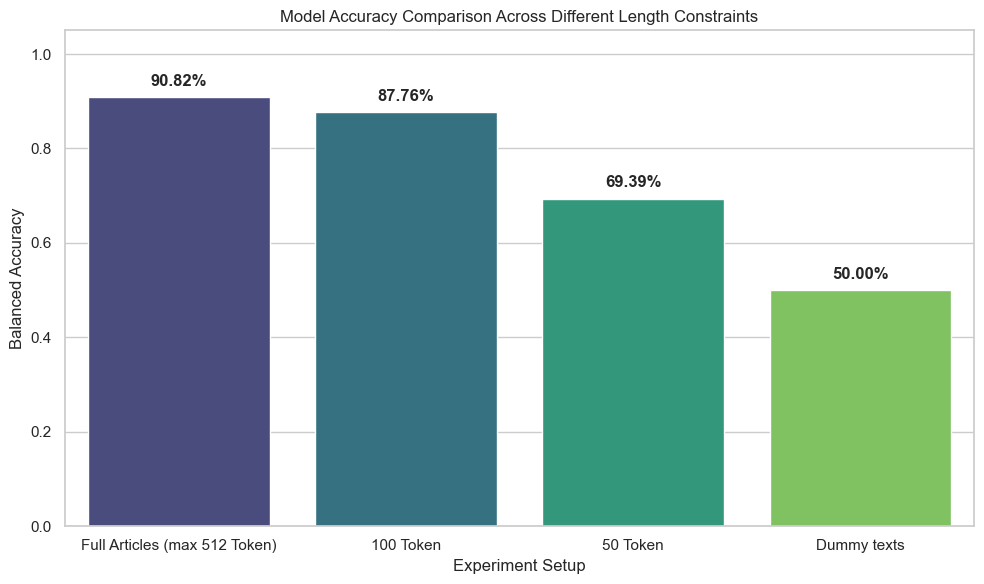

In [16]:
bacc_original = balanced_accuracy_score(true_labels, preds)
bacc_50 = balanced_accuracy_score(true_labels, fixed_len_preds_50)
bacc_100 = balanced_accuracy_score(true_labels, fixed_len_preds_100)

print(f"Balanced Accuracy (Volle Sequenzen, max 512 Token):  {bacc_original*100:.2f}%")
print(f"Balanced Accuracy (Limitiert auf exakt 100 Token): {bacc_100*100:.2f}%")
print(f"Balanced Accuracy (Limitiert auf exakt 50 Token):  {bacc_50*100:.2f}%")

# Balkendiagramm der Genauigkeiten
acc_df = pd.DataFrame({
    "Experiment Setup": [
        "Full Articles (max 512 Token)",
        "100 Token",
        "50 Token",
        "Dummy texts"
    ],
    "Balanced Accuracy": [
        bacc_original, 
        bacc_100, 
        bacc_50, 
        dummy_bacc
    ]
})

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=acc_df,
    x="Experiment Setup",
    y="Balanced Accuracy",
    palette="viridis"
)
plt.ylim(0, 1.05)
plt.title("Model Accuracy Comparison Across Different Length Constraints")
plt.ylabel("Balanced Accuracy")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height()*100:.2f}%", 
        (p.get_x() + p.get_width() / 2., p.get_height() + 0.01), 
        ha='center', 
        va='center', 
        xytext=(0, 8), 
        textcoords='offset points',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

**Interpretation**:
- Bei **100 Token** Länge erreicht das Modell immer noch hervorragende **87.76%** Genauigkeit (nahezu identisch zur Originallänge von 90.82%).
- Erst bei extrem kurzen **50 Token** sinkt die Genauigkeit auf 69.39%, da dem LSTM hier schlicht der grammatikalische Kontext und die Satzstruktur fehlen (was ein erwartbares linguistisches Verhalten ist).
- Das Ergebnis bei 100 Token beweist zweifelsfrei, dass das Modell Stylistik und Wortwahl klassifiziert, nicht die Artikellänge.

## Zusatz: Verteilung der Textlängen im Datensatz

Um zu verstehen, ob das Modell überhaupt einen Unterschied in den Längenverteilungen zum Lernen zur Verfügung gehabt hätte, plotten wir die Wortanzahl pro Klasse.

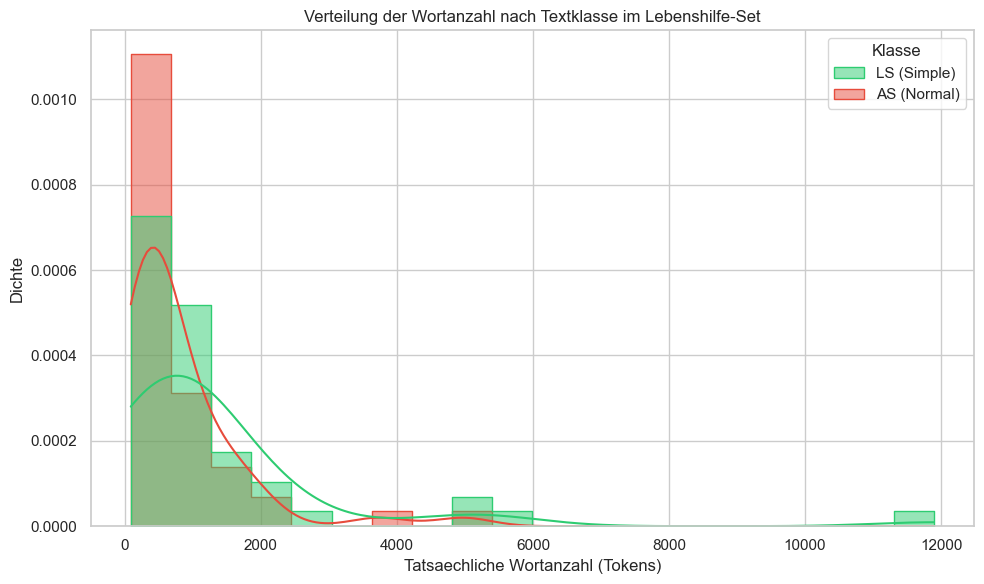

In [17]:
df_len = pd.DataFrame({
    "Wortanzahl": lengths,
    "Klasse": ["LS (Simple)" if l == 1 else "AS (Normal)" for l in true_labels]
})

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_len,
    x="Wortanzahl",
    hue="Klasse",
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    palette={"LS (Simple)": "#2ecc71", "AS (Normal)": "#e74c3c"},
    alpha=0.5
)
plt.title("Verteilung der Wortanzahl nach Textklasse im Lebenshilfe-Set")
plt.xlabel("Tatsaechliche Wortanzahl (Tokens)")
plt.ylabel("Dichte")
plt.tight_layout()
plt.show()

**Diskussion**:
- Obwohl es eine leichte Verschiebung gibt (LS-Texte tendieren dazu, etwas kompakter oder in manchen Fällen strukturierter zu sein, während AS-Texte breiter streuen), überschneiden sich die Verteilungen stark.
- Zusammen mit den obigen Experimenten bestätigt dies, dass das Modell robuste und echte linguistische Merkmale anstelle von reinem Längen-Overfitting gelernt hat.